## Finding the most frequent  in each year

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import os

In [13]:
def get_most_frequent_words(dataframe, year_col, ad_cols, top_n=20): #gon make all the functions to use later in the loops!
    yearly_word_counts = {}

    for index, row in dataframe.iterrows(): #iterate for every year
        year = row[year_col]
        all_ads = " ".join(str(row[col]) for col in ad_cols if not pd.isna(row[col]))
        word_counts = Counter(all_ads.split())
        most_common_words = word_counts.most_common(top_n)
        yearly_word_counts[year] = most_common_words

    return yearly_word_counts

def plot_word_frequencies(yearly_word_counts, color):
    for year, word_data in yearly_word_counts.items():
        words, counts = zip(*word_data)
        plt.figure(figsize=(9, 5))
        plt.bar(words, counts, color=color)
        plt.title(f"Top {len(words)} words: {year}")
        plt.xlabel("Words")
        plt.ylabel("Frequency")
        plt.xticks(rotation=45, ha="right")
        save_path = os.path.join(save_dir, f"{party}_{year}_topfreq.png")
        plt.savefig(save_path)
        plt.show()
        
    

        #plt.close()

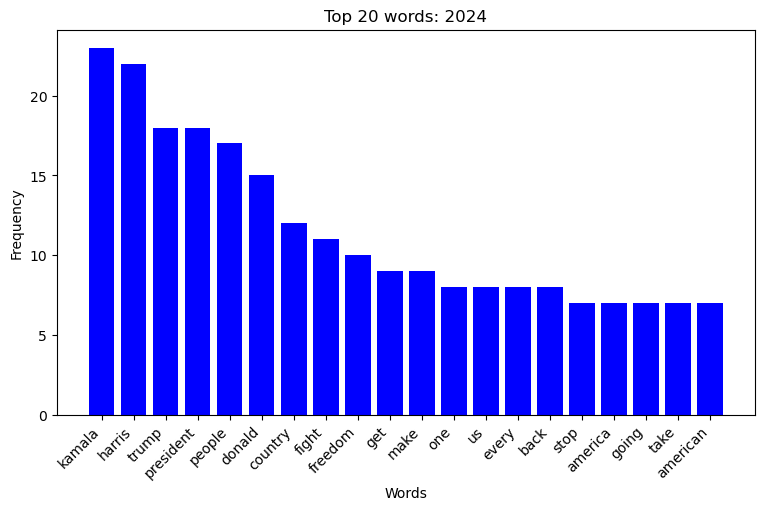

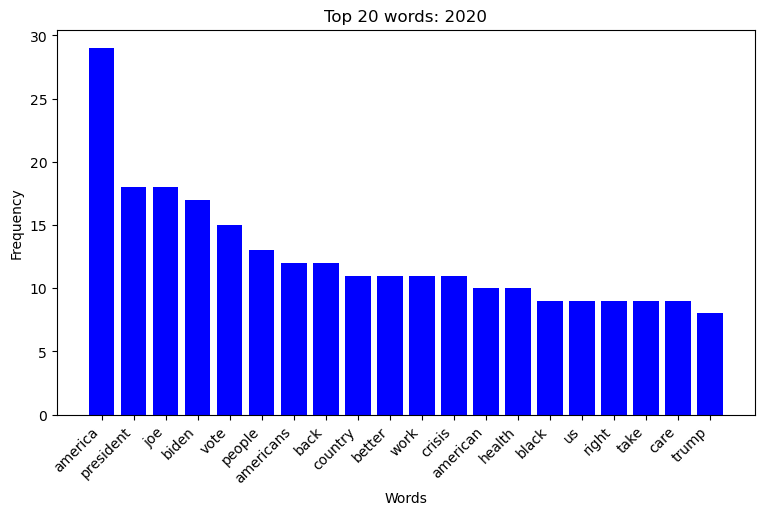

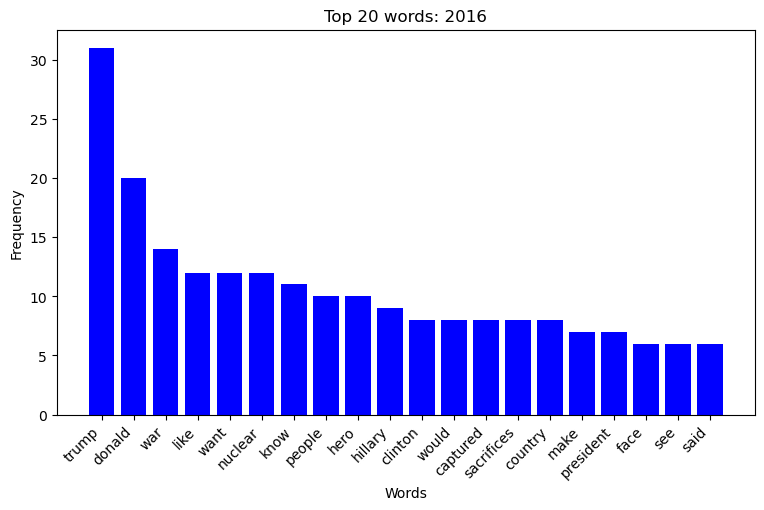

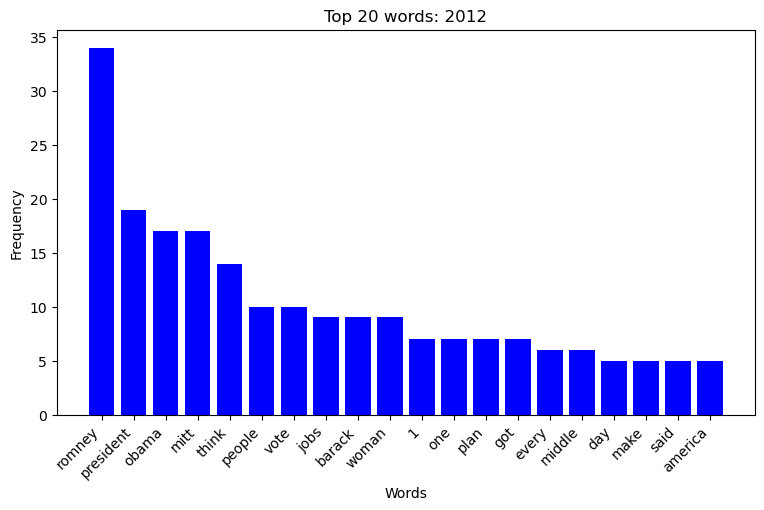

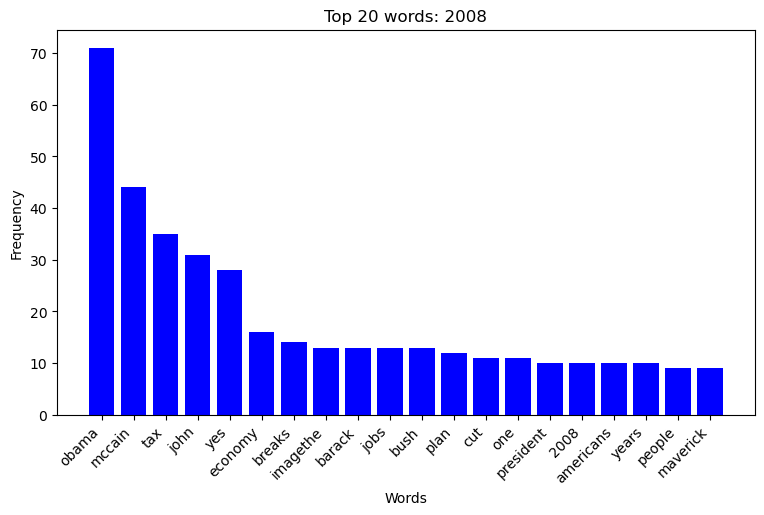

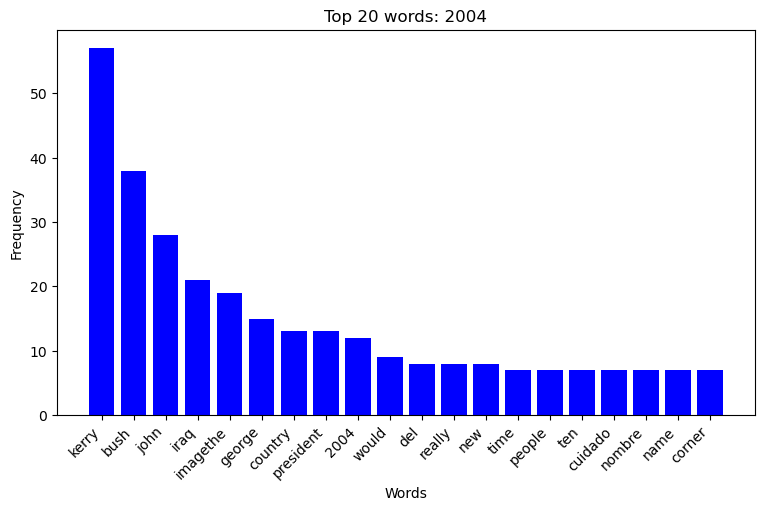

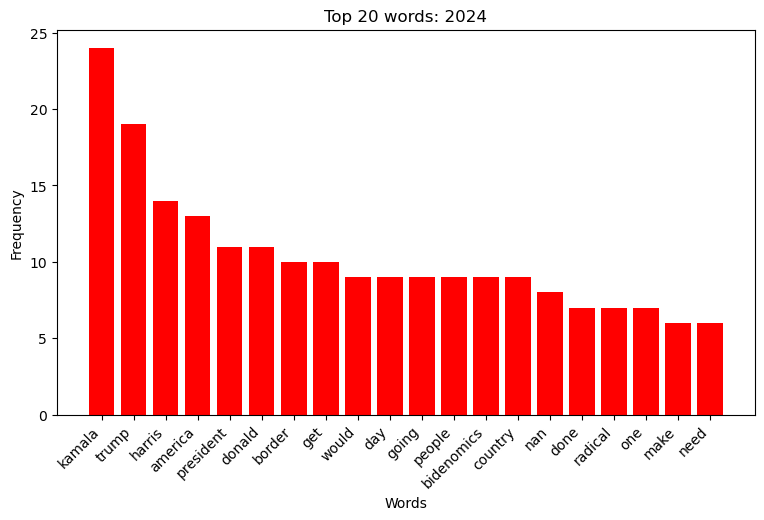

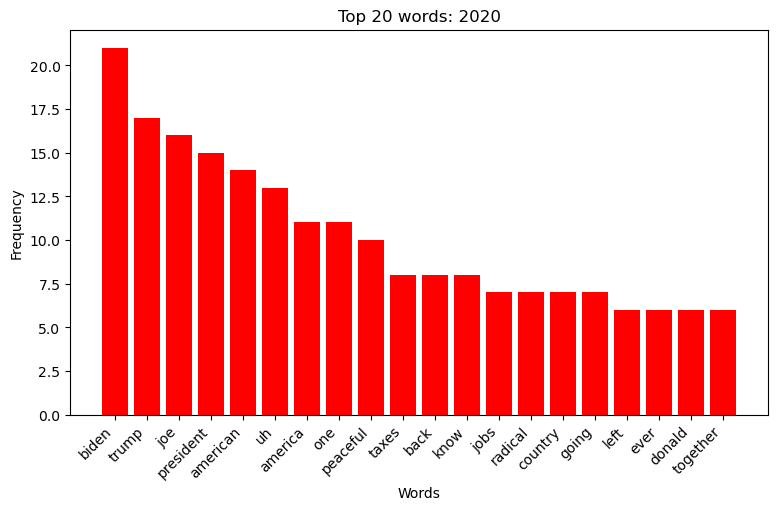

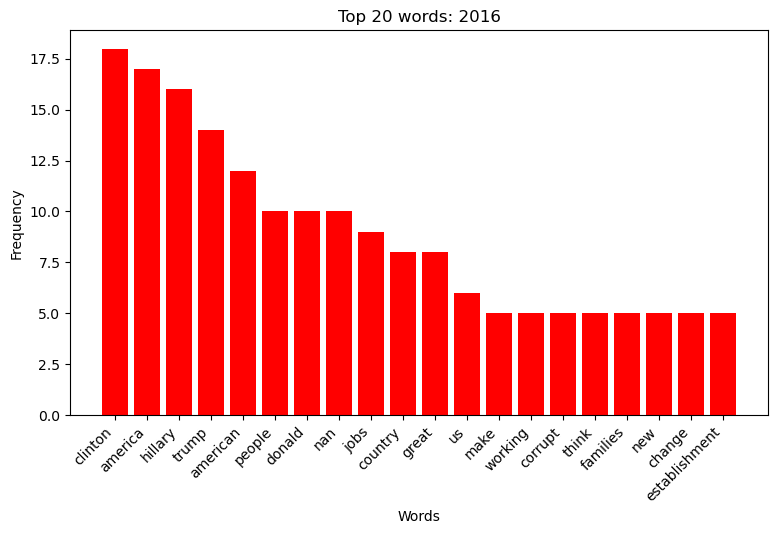

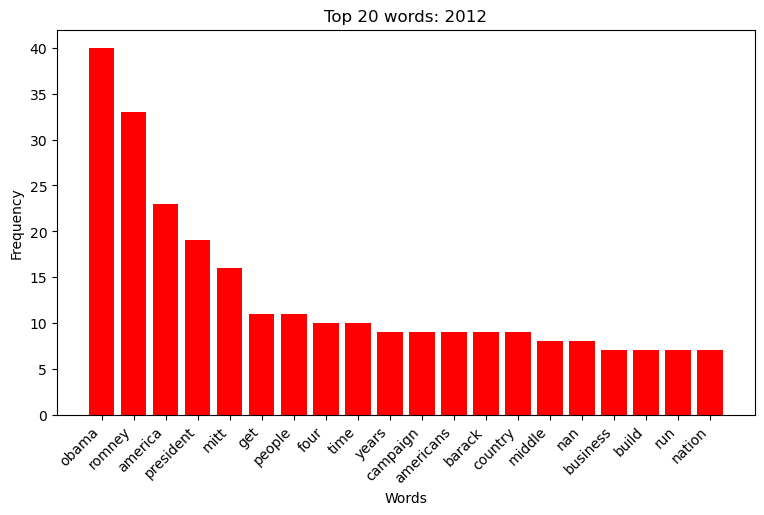

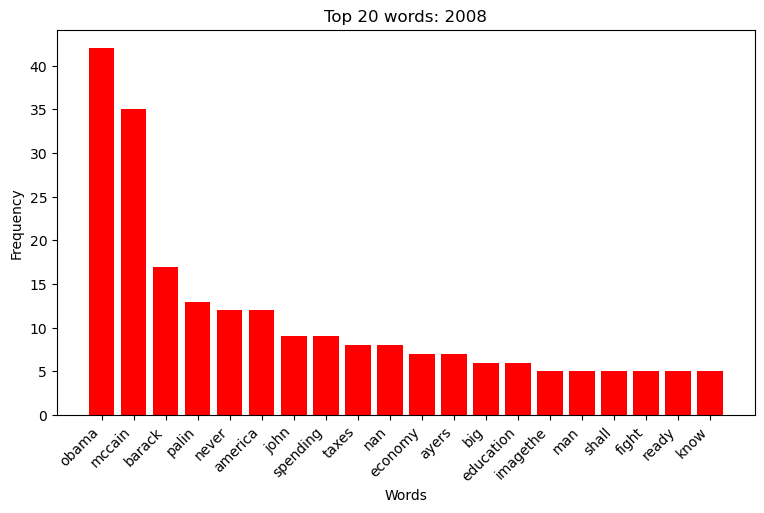

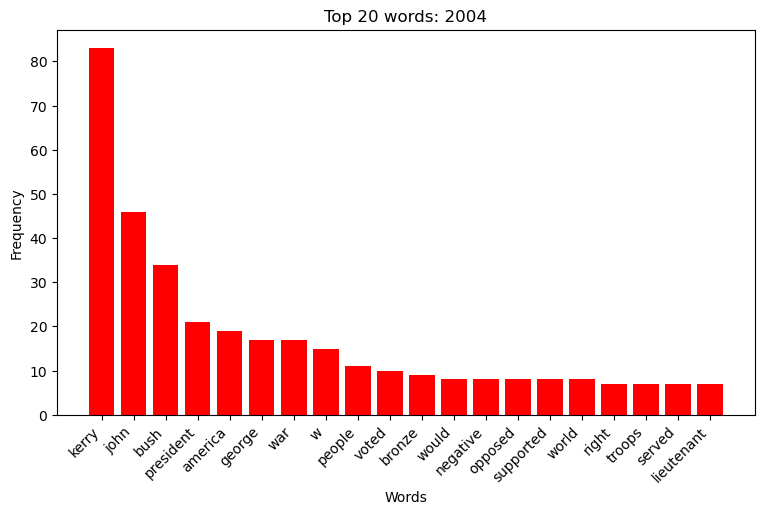

In [14]:
dems_file = "/Users/inqsoncharoen/Documents/Election_Analysis/combined_dems.csv"
repub_file = "/Users/inqsoncharoen/Documents/Election_Analysis/combined_repub.csv"

#this is to load in data
dems_df = pd.read_csv(dems_file)
repub_df = pd.read_csv(repub_file)

save_dir = "/Users/inqsoncharoen/Documents/Election_Analysis/Figures/MostFreq"  
os.makedirs(save_dir, exist_ok=True)

for df, party, color in [(dems_df, "Democrats", "blue"), (repub_df, "Republicans", "red")]:
    year_col = df.columns[0]  #first col is year
    ad_cols = df.columns[1:]  #rest of the cols are ads
    yearly_word_counts = get_most_frequent_words(df, year_col, ad_cols)
    plot_word_frequencies(yearly_word_counts, color)
    


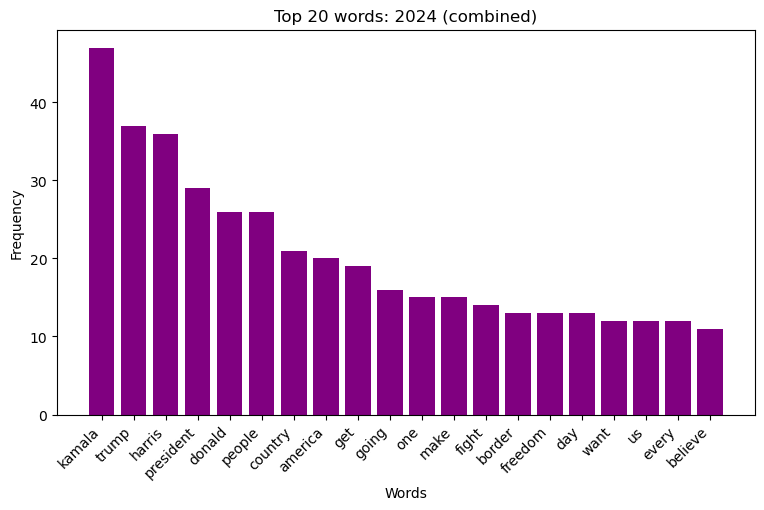

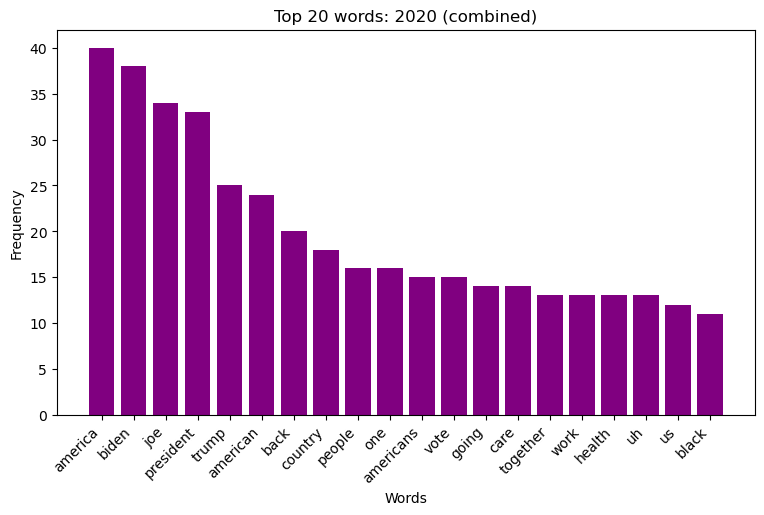

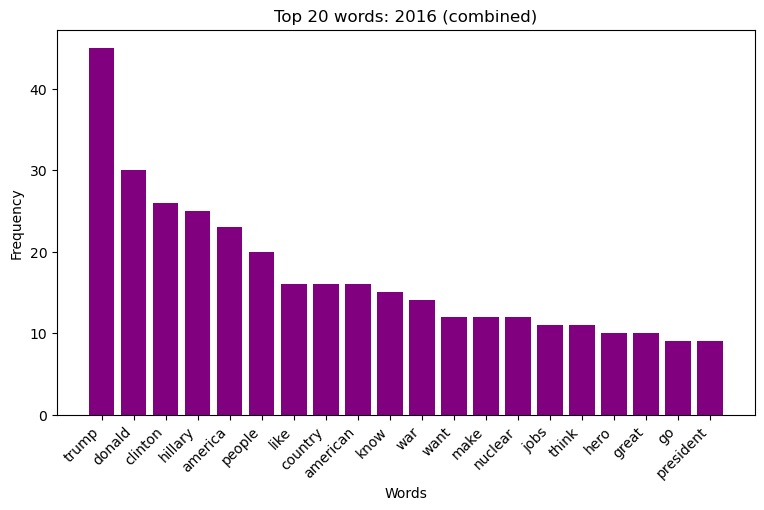

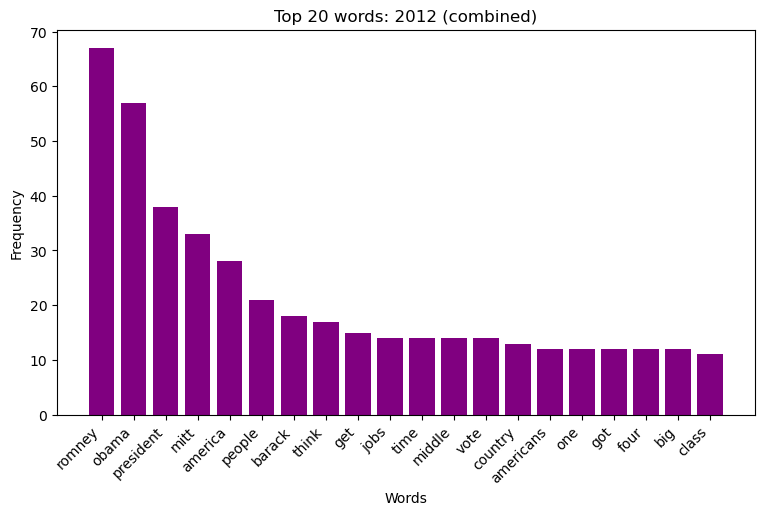

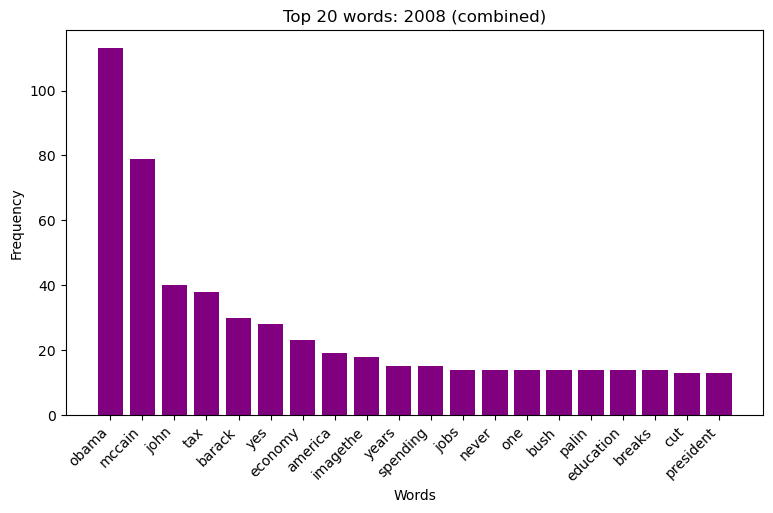

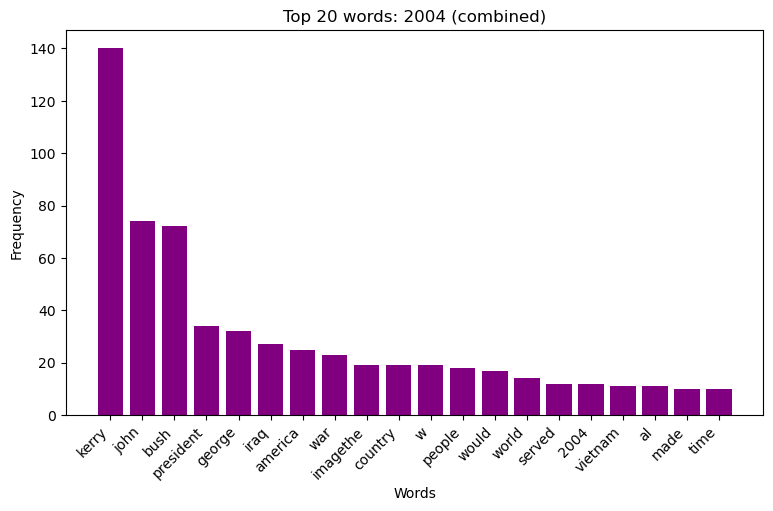

In [18]:
def plot_combined_frequencies(dems_df, repub_df, year_col, ad_cols, top_n=20):
    combined_yearly_counts = {}

    for df in [dems_df, repub_df]:
        for index, row in df.iterrows(): #iterate through rows in loops
            year = row[year_col]
            all_ads = " ".join(str(row[col]) for col in ad_cols if not pd.isna(row[col])) #isna to detect null in df
            if year not in combined_yearly_counts:
                combined_yearly_counts[year] = all_ads
            else:
                combined_yearly_counts[year] += " " + all_ads

    yearly_word_counts = {} #make dict for word count
    for year, text in combined_yearly_counts.items():
        word_counts = Counter(text.split())
        yearly_word_counts[year] = word_counts.most_common(top_n)

    for year, word_data in yearly_word_counts.items(): #plot for each one
        words, counts = zip(*word_data)
        plt.figure(figsize=(9, 5))
        plt.bar(words, counts, color="purple")
        plt.title(f"Top {len(words)} words: {year} (combined)")
        plt.xlabel("Words")
        plt.ylabel("Frequency")
        plt.xticks(rotation=45, ha="right")
        plt.show()

plot_combined_frequencies(dems_df, repub_df, dems_df.columns[0], dems_df.columns[1:], top_n=20)

In [ ]:
#in case of saving all the figs, go fix code above
#import os
# filename = "FileName.png"
# filepath = os.path.join(FilePathName, filename)
# plt.savefig(filepath)